# Task 1 – EDA: Fraud_Data.csv

Exploratory Data Analysis for the e-commerce transaction dataset.
We cover:
1. Data loading & shape inspection
2. Missing values & duplicates
3. Data-type corrections
4. Univariate distributions
5. Bivariate analysis (feature vs. target)
6. Class-imbalance quantification
7. Geolocation enrichment (IP → Country)
8. Fraud patterns by country


## 1. Imports & display settings

In [3]:
# ── 1. Imports & display settings ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make plots readable inside the notebook
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
print("Imports OK")


Imports OK


## 2. Load raw data

In [4]:
# ── 2. Load raw data ───────────────────────────────────────────────────────────
DATA_RAW = '../data/raw/'

fraud  = pd.read_csv(DATA_RAW + 'Fraud_Data.csv')
ip_map = pd.read_csv(DATA_RAW + 'IpAddress_to_Country.csv')

print(f"Fraud_Data  : {fraud.shape[0]:,} rows × {fraud.shape[1]} cols")
print(f"IP_to_Country: {ip_map.shape[0]:,} rows × {ip_map.shape[1]} cols")
fraud.head(3)


Fraud_Data  : 151,112 rows × 11 cols
IP_to_Country: 138,846 rows × 3 cols


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1


## 3. Data Cleaning

In [3]:
# ── 3a. Missing values ────────────────────────────────────────────────────────
print("Missing values per column:")
print(fraud.isnull().sum())
# Justification: if any column has nulls we will handle them below;
# given this is transaction data, we prefer to drop rows with missing
# targets and impute median for numerical columns.


Missing values per column:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


In [4]:
# ── 3b. Duplicate rows ────────────────────────────────────────────────────────
dupes = fraud.duplicated().sum()
print(f"Duplicate rows: {dupes}")
fraud = fraud.drop_duplicates()
print(f"Shape after removing duplicates: {fraud.shape}")


Duplicate rows: 0
Shape after removing duplicates: (151112, 11)


In [5]:
# ── 3c. Correct data types ────────────────────────────────────────────────────
# signup_time and purchase_time are strings → convert to datetime
fraud['signup_time']   = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time'])

# class is already int (0/1) – confirm
print(fraud.dtypes)
print()
print(fraud.describe(include='all').T)

user_id                    int64
signup_time       datetime64[us]
purchase_time     datetime64[us]
purchase_value             int64
device_id                    str
source                       str
browser                      str
sex                          str
age                        int64
ip_address               float64
class                      int64
dtype: object

                   count  unique            top   freq  \
user_id         151112.0     NaN            NaN    NaN   
signup_time       151112     NaN            NaN    NaN   
purchase_time     151112     NaN            NaN    NaN   
purchase_value  151112.0     NaN            NaN    NaN   
device_id         151112  137956  ITUMJCKWEYNDD     20   
source            151112       3            SEO  60615   
browser           151112       5         Chrome  61432   
sex               151112       2              M  88293   
age             151112.0     NaN            NaN    NaN   
ip_address      151112.0     NaN          

## 4. Univariate Distributions

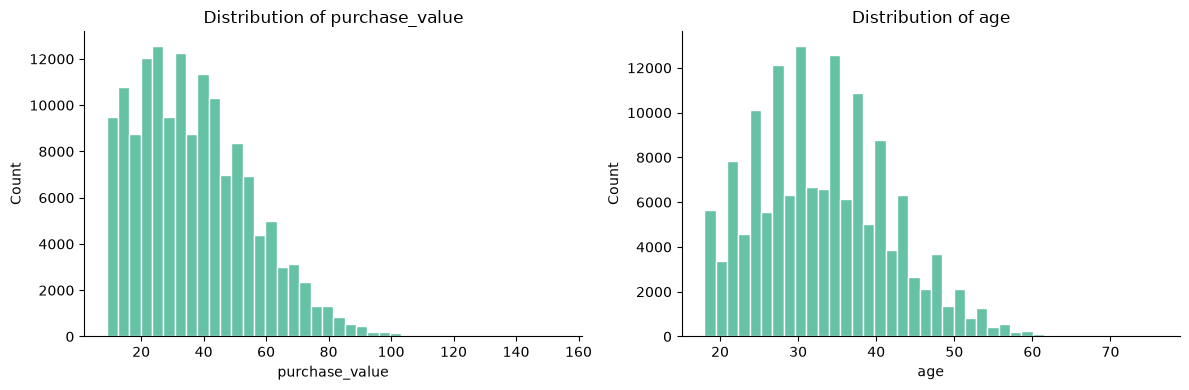

Saved: eda_numeric_dist.png


In [6]:
# ── 4a. Numerical distributions ───────────────────────────────────────────────
num_cols = ['purchase_value', 'age']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(fraud[col], bins=40, edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/eda_numeric_dist.png', dpi=100)
plt.show()
print("Saved: eda_numeric_dist.png")

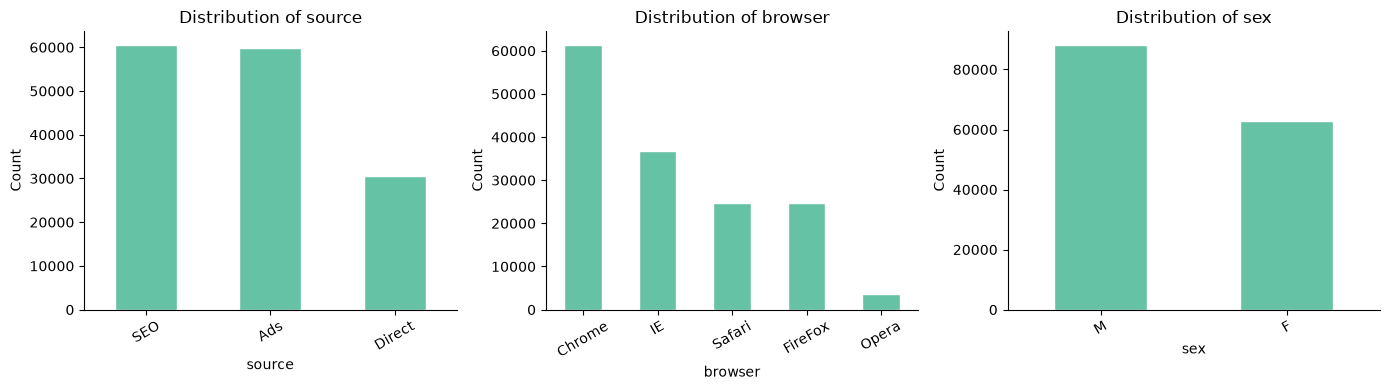

In [7]:
# ── 4b. Categorical distributions ─────────────────────────────────────────────
cat_cols = ['source', 'browser', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, cat_cols):
    fraud[col].value_counts().plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/eda_categorical_dist.png', dpi=100)
plt.show()


## 5. Class Imbalance

Legitimate (0): 136,961  (90.6%)
Fraud      (1): 14,151  (9.4%)


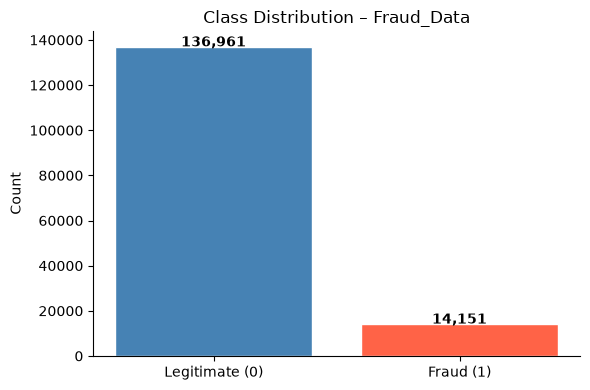


Fraud ratio: 9.36% — highly imbalanced, requires special handling.


In [8]:
# ── 5. Quantify class imbalance ───────────────────────────────────────────────
class_counts = fraud['class'].value_counts()
fraud_pct    = class_counts[1] / len(fraud) * 100

print(f"Legitimate (0): {class_counts[0]:,}  ({100 - fraud_pct:.1f}%)")
print(f"Fraud      (1): {class_counts[1]:,}  ({fraud_pct:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Legitimate (0)', 'Fraud (1)'], class_counts.values,
       color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Class Distribution – Fraud_Data')
ax.set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/eda_class_imbalance.png', dpi=100)
plt.show()
print(f"\nFraud ratio: {fraud_pct:.2f}% — highly imbalanced, requires special handling.")

## 6. Bivariate Analysis (Feature vs Target)

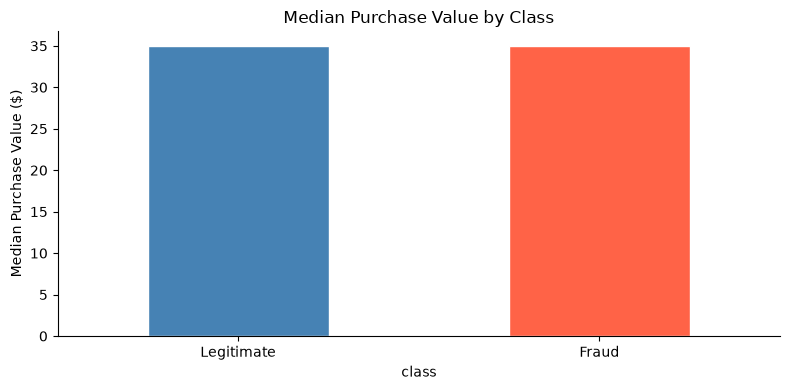

In [9]:
# ── 6a. Purchase value vs class ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
fraud.groupby('class')['purchase_value'].median().plot(
    kind='bar', ax=ax, color=['steelblue','tomato'], edgecolor='white')
ax.set_title('Median Purchase Value by Class')
ax.set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
ax.set_ylabel('Median Purchase Value ($)')
plt.tight_layout()
plt.savefig('../data/processed/eda_purchase_vs_class.png', dpi=100)
plt.show()


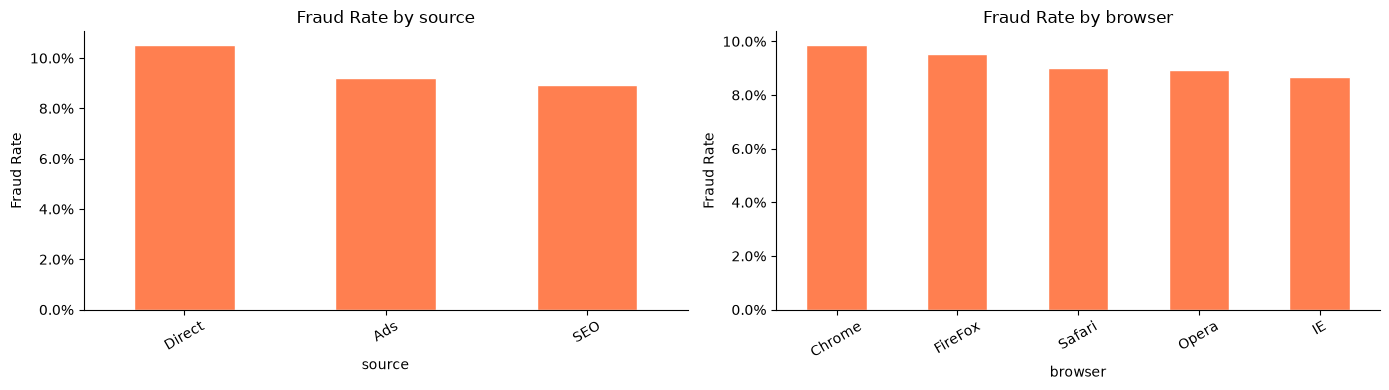

In [10]:
# ── 6b. Fraud rate by source & browser ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ['source', 'browser']):
    rate = fraud.groupby(col)['class'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, edgecolor='white', color='coral')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.savefig('../data/processed/eda_fraud_rate_by_cat.png', dpi=100)
plt.show()


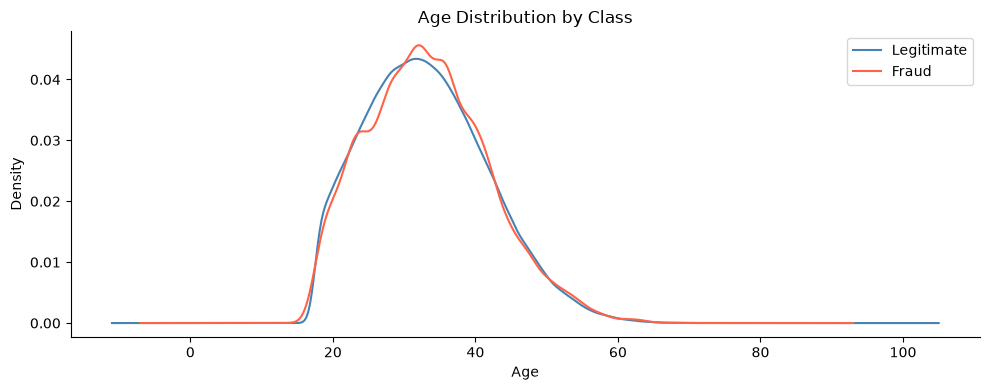

In [11]:
# ── 6c. Age distribution by class ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for cls, label, color in [(0,'Legitimate','steelblue'), (1,'Fraud','tomato')]:
    fraud[fraud['class'] == cls]['age'].plot(
        kind='kde', ax=ax, label=label, color=color)
ax.set_title('Age Distribution by Class')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/eda_age_by_class.png', dpi=100)
plt.show()


## 7. Geolocation Integration (IP → Country)

In [12]:
# ── 7a. Convert IP to integer ────────────────────────────────────────────────
# ip_address in Fraud_Data is already a float representation of the IP integer.
# We cast it to int64 to match the bounds in IpAddress_to_Country.csv.
fraud['ip_int'] = fraud['ip_address'].astype(np.int64)

print("Sample ip_int values:")
print(fraud[['ip_address', 'ip_int']].head(5))

Sample ip_int values:
     ip_address      ip_int
0  7.327584e+08   732758368
1  3.503114e+08   350311387
2  2.621474e+09  2621473820
3  3.840542e+09  3840542443
4  4.155831e+08   415583117


In [16]:
# ── 7b. Range-based IP merge ──────────────────────────────────────────────
# Convert ALL merge keys to int64 (required by merge_asof)

fraud = fraud.copy()
ip_sorted = ip_map.copy()

fraud["ip_int"] = fraud["ip_int"].astype(np.int64)

ip_sorted["lower_bound_ip_address"] = (
    ip_sorted["lower_bound_ip_address"].astype(np.int64)
)
ip_sorted["upper_bound_ip_address"] = (
    ip_sorted["upper_bound_ip_address"].astype(np.int64)
)

# Sort before merge_asof
ip_sorted = (
    ip_sorted
    .sort_values("lower_bound_ip_address")
    .reset_index(drop=True)
)

fraud_sorted = (
    fraud
    .sort_values("ip_int")
    .reset_index(drop=True)
)

# Range lookup: find largest lower_bound <= ip_int
fraud_geo = pd.merge_asof(
    fraud_sorted,
    ip_sorted[
        [
            "lower_bound_ip_address",
            "upper_bound_ip_address",
            "country",
        ]
    ],
    left_on="ip_int",
    right_on="lower_bound_ip_address",
    direction="backward",
)

# Keep rows whose IP falls inside the matched range
in_range = (
    fraud_geo["ip_int"]
    <= fraud_geo["upper_bound_ip_address"]
)

fraud_geo.loc[~in_range, "country"] = "Unknown"

# Optional: remove helper columns
fraud_geo.drop(
    columns=[
        "lower_bound_ip_address",
        "upper_bound_ip_address",
    ],
    inplace=True,
    errors="ignore",
)

print(f"Rows before geo-merge : {len(fraud):,}")
print(f"Rows after geo-merge  : {len(fraud_geo):,}")
print(f"Unknown countries     : {(fraud_geo['country'] == 'Unknown').sum():,}")
print(f"Unique countries found: {fraud_geo['country'].nunique()}")

fraud_geo[["ip_address", "ip_int", "country"]].head()

Rows before geo-merge : 151,112
Rows after geo-merge  : 151,112
Unknown countries     : 21,966
Unique countries found: 182


,ip_address,ip_int,country
0,52093.496895,52093,Unknown
1,93447.138961,93447,Unknown
2,105818.501505,105818,Unknown
3,117566.664867,117566,Unknown
4,131423.789042,131423,Unknown


Top-10 countries by transaction volume:
                   total  fraud  fraud_rate
country                                    
United States      58049   5551    0.095626
Unknown            21966   1883    0.085723
China              12038   1043    0.086642
Japan               7306    715    0.097865
United Kingdom      4490    477    0.106236
Korea Republic of   4162    380    0.091302
Germany             3646    262    0.071860
France              3161    300    0.094907
Canada              2975    348    0.116975
Brazil              2961    270    0.091185


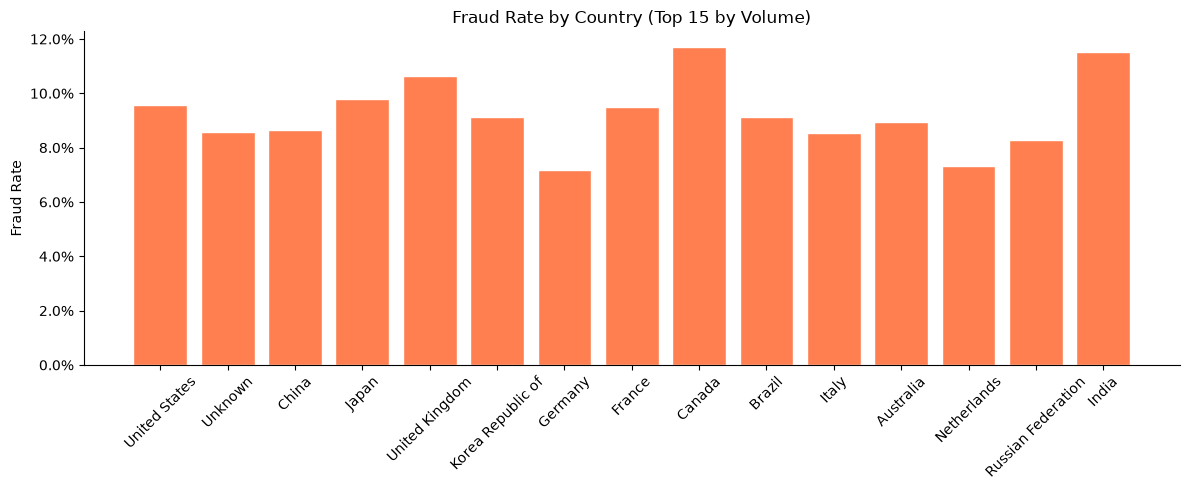

In [17]:
# ── 7c. Fraud patterns by country ────────────────────────────────────────────
country_stats = (
    fraud_geo.groupby('country')
    .agg(total=('class', 'count'), fraud=('class', 'sum'))
    .assign(fraud_rate=lambda d: d['fraud'] / d['total'])
    .sort_values('total', ascending=False)
)

print("Top-10 countries by transaction volume:")
print(country_stats.head(10).to_string())

# Plot fraud rate for top-15 countries by volume
top15 = country_stats.head(15).copy()
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top15.index, top15['fraud_rate'], color='coral', edgecolor='white')
ax.set_title('Fraud Rate by Country (Top 15 by Volume)')
ax.set_ylabel('Fraud Rate')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
plt.tight_layout()
plt.savefig('../data/processed/eda_fraud_by_country.png', dpi=100)
plt.show()


## 8. Save Cleaned EDA Output

In [18]:
# ── 8. Save geo-enriched fraud data for feature engineering ──────────────────
fraud_geo.to_csv('../data/processed/fraud_geo.csv', index=False)
print("Saved: data/processed/fraud_geo.csv")
print(fraud_geo.columns.tolist())


Saved: data/processed/fraud_geo.csv
['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'ip_int', 'country']
